# Force regularization

This notebook analyzes the short-range behavior of the pairwise force used in the oncostream model. For better comprehension, read the text in the folder. All calculations are analytical evaluations of the pairwise force.

In [1]:
# Import necessary libraries
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Create a directory for figures if it doesn't exist
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

# Set default plotting parameters for matplotlib
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)

# Default model parameters
K_REP = 10 / 3
RADIUS = 1.0
GAMMA = 3.0

## 1. Pairwise force laws

As derived in the accompanying document, for two identical round cells of radius $R$, the normalized overlap is

$$
\xi(r)
=
\exp\left(-\frac{r^2}{4R^2}\right),
$$

and the magnitude of the original force is

$$
f_0(r;\gamma)
=
\frac{k\gamma}{2R^2}\,
r\,
\exp\left(-\frac{\gamma r^2}{4R^2}\right).
$$

The first figure examines this expression in two complementary ways: as a function of $r$ at fixed $\gamma$, and as a function of $\gamma$ at the fixed separation $r=2R$. In the latter case,

$$
f_0(\gamma;r=2R)
=
\frac{k}{R}\gamma e^{-\gamma}.
$$

The same expression can be generalized to two identical and aligned elliptical cells approaching along one of their common principal axes:

$$
f_0(r;\gamma)
=
\frac{k\gamma}{2a^2}\,
r\,
\exp\left(-\frac{\gamma r^2}{4a^2}\right),
$$

where $a=l_{\parallel}$ or $a=l_{\perp}$ is the semi-axis along the direction of approach.

The regularized force is

$$
f_\lambda(r)
=
f_0(r)
\left[
1+
\lambda
\frac{\xi(r)^\gamma}
{1-\xi(r)^\gamma}
\right].
$$

The corresponding force amplification is

$$
\frac{f_\lambda}{f_0}
=
1+
\lambda
\frac{\xi^\gamma}
{1-\xi^\gamma}.
$$

The numerical values of $R$, $k$, and $\gamma$ used in each figure are specified at the beginning of the notebook.

In [2]:
# Function to get cell semi-axes
def cell_semiaxes(aspect_ratio, reference_radius=RADIUS):
    """Return the major and minor semi-axes at fixed cell area."""
    major = reference_radius * np.sqrt(aspect_ratio)
    minor = reference_radius / np.sqrt(aspect_ratio)
    return major, minor

# Function to compute normalized overlap along one principal axis
def overlap_along_axis(distance, semi_axis):
    """Return the normalized overlap along one principal axis."""
    return np.exp(-distance**2 / (4 * semi_axis**2))

# Function to compute original force along one principal axis
def original_force_axis(
    distance,
    semi_axis,
    gamma=GAMMA,
    k_rep=K_REP,
):
    """Return the original force magnitude along a principal axis."""
    # Compute the exponent for the force calculation
    exponent = gamma * distance**2 / (4 * semi_axis**2)
    # Return the original force magnitude along the principal axis
    return (
        k_rep
        * gamma
        / (2 * semi_axis**2)
        * distance
        * np.exp(-exponent)
    )


# Function to compute regularized force along one principal axis
def regularized_force_axis(
    distance,
    semi_axis,
    lambda_core,
    gamma=GAMMA,
    k_rep=K_REP,
):
    """Return the regularized force magnitude along a principal axis."""
    # Compute the original force along the principal axis
    original = original_force_axis(
        distance=distance,
        semi_axis=semi_axis,
        gamma=gamma,
        k_rep=k_rep,
    )

    # If lambda_core is close to zero, return the original force
    if np.isclose(lambda_core, 0.0):
        return original

    # Compute the overlap power for the regularization
    overlap_power = np.exp(
        -gamma * distance**2 / (4 * semi_axis**2)
    )

    # Compute the correction factor for the regularized force
    correction = (
        1
        + lambda_core
        * overlap_power
        / (1 - overlap_power)
    )

    # Return the regularized force along the principal axis
    return original * correction


def force_amplification(normalized_overlap, lambda_core, gamma=GAMMA):
    """Return the ratio between regularized and original forces."""
    # Compute the overlap power for the amplification calculation
    overlap_power = normalized_overlap**gamma
    # Return the amplification factor based on the overlap power and lambda_core
    return (
        1
        + lambda_core
        * overlap_power
        / (1 - overlap_power)
    )


def save_figure(fig, stem):
    """Save one figure in vector and raster formats."""
    fig.savefig(
        FIGURE_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

## 2. Original force

Let's plot the behaviour of the original force. We see how it changes with $\gamma$ and $r$.

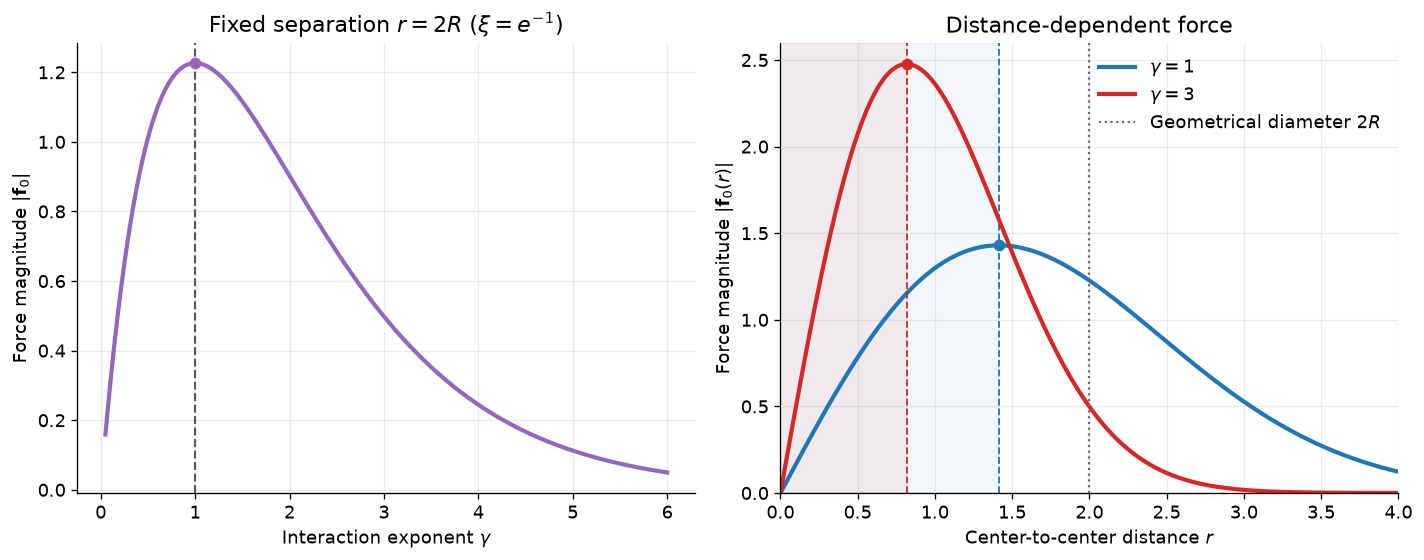

In [3]:
# Generate a range of gamma values for analysis
gamma_values = np.linspace(0.05, 6.0, 1_500)
# Set a fixed distance for force calculations
fixed_distance = 2 * RADIUS

# Compute the force at the fixed distance for each gamma value
force_at_fixed_distance = np.array(
    [
        original_force_axis(
            distance=fixed_distance,
            semi_axis=RADIUS,
            gamma=gamma,
        )
        for gamma in gamma_values
    ]
)

# Create a figure with two subplots to visualize the force behavior
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)

# First subplot
# Plot the force magnitude at fixed distance as a function of gamma
axes[0].plot(
    gamma_values,
    force_at_fixed_distance,
    color="tab:purple",
    linewidth=2.5,
)
# Plot a line in gamma=1
axes[0].axvline(
    1,
    color="0.35",
    linestyle="--",
    linewidth=1.3,
)
# Point in the maximum value
axes[0].scatter(
    [1],
    [original_force_axis(fixed_distance, RADIUS, gamma=1)],
    color="tab:purple",
    zorder=3,
)
# Settings
axes[0].set(
    xlabel=r"Interaction exponent $\gamma$",
    ylabel=r"Force magnitude $|\mathbf{f}_0|$",
    title=r"Fixed separation $r=2R$ ($\xi=e^{-1}$)",
)

# Generate a range of distances for the second subplot
distance = np.linspace(0, 4 * RADIUS, 2_000)
gamma_colors = {1: "tab:blue", 3: "tab:red"}

# For each gamma value, compute and plot the force as a function of distance
for gamma in [1, 3]:
    # Compute the original force along the principal axis for the given distance and gamma
    force = original_force_axis(
        distance=distance,
        semi_axis=RADIUS,
        gamma=gamma,
    )
    # Compute the distance at which the force reaches its peak value
    peak_distance = RADIUS * np.sqrt(2 / gamma)
    # Compute the peak force at the peak distance for the given gamma
    peak_force = original_force_axis(
        distance=peak_distance,
        semi_axis=RADIUS,
        gamma=gamma,
    )
    # Plot the force as a function of distance for the current gamma value
    axes[1].plot(
        distance,
        force,
        color=gamma_colors[gamma],
        linewidth=2.5,
        label=rf"$\gamma={gamma}$",
    )
    # Highlight the area under the curve up to the peak distance
    axes[1].axvspan(
        0,
        peak_distance,
        color=gamma_colors[gamma],
        alpha=0.06,
    )
    # Add a vertical line and scatter point at the peak distance and force
    axes[1].axvline(
        peak_distance,
        color=gamma_colors[gamma],
        linestyle="--",
        linewidth=1.1,
    )
    axes[1].scatter(
        [peak_distance],
        [peak_force],
        color=gamma_colors[gamma],
        zorder=3,
    )

# Add a vertical line at the geometrical diameter (2R) for reference
axes[1].axvline(
    2 * RADIUS,
    color="0.4",
    linestyle=":",
    linewidth=1.3,
    label=r"Geometrical diameter $2R$",
)
# Settings
axes[1].set(
    xlabel=r"Center-to-center distance $r$",
    ylabel=r"Force magnitude $|\mathbf{f}_0(r)|$",
    title="Distance-dependent force",
    xlim=(0, 4 * RADIUS),
    ylim=(0, None),
)
axes[1].legend()


fig.tight_layout()

save_figure(fig, "original_force_analysis")
plt.show()

The left panel holds the geometry fixed and varies $\gamma$; the right panel holds $\gamma$ fixed and varies the separation. These are different comparisons. For $\gamma=1$, the interaction can be stronger at the beginning of a collision, but the decreasing inner branch starts at a much smaller overlap, $\xi_*=0.607$, than for $\gamma=3$, where $\xi_*=0.846$.

## 3. Regularization for two round cells

For two identical round cells of radius $R$,

$$
\xi(r)=\exp\left(-\frac{r^2}{4R^2}\right),
$$

and the regularized force is

$$
f_\lambda(r)
=f_0(r)
\left[1+\lambda\frac{\xi(r)^\gamma}{1-\xi(r)^\gamma}\right].
$$

The first panel compares the complete force curves. The second panel isolates the multiplicative correction as a function of normalized overlap.

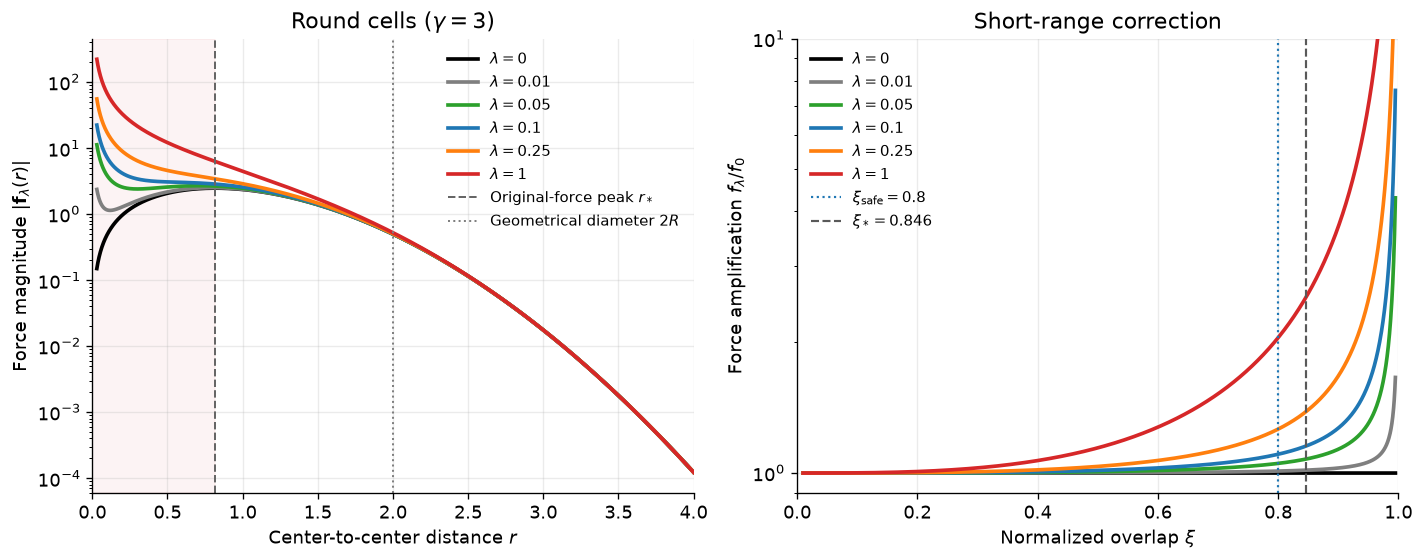

In [4]:
# Take values for lambda
lambda_cores = [0.0, 0.01, 0.05, 0.1, 0.25, 1.0]
core_colors = {
    0.0: "black",
    0.01: "tab:gray",
    0.05: "tab:green",
    0.1: "tab:blue",
    0.25: "tab:orange",
    1.0: "tab:red",
}

# Generate a range of distances and normalized overlaps for analysis
distance = np.linspace(0.03, 4 * RADIUS, 4_000)
normalized_overlap = np.linspace(0.01, 0.995, 2_000)
# Compute the peak distance and peak overlap for the regularized force analysis
peak_distance = RADIUS * np.sqrt(2 / GAMMA)
peak_overlap = np.exp(-1 / (2 * GAMMA))
# Choose a safe overlap value
safe_overlap = 0.8

# Create a figure with two subplots
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)

# For each lambda plot the forces
for lambda_core in lambda_cores:
    # Compute the regularized force
    force = regularized_force_axis(
        distance=distance,
        semi_axis=RADIUS,
        lambda_core=lambda_core,
    )
    # First subplot
    # Plot the force vs the distance
    axes[0].plot(
        distance,
        force,
        color=core_colors[lambda_core],
        linewidth=2.2,
        label=rf"$\lambda={lambda_core:g}$",
    )

# Highlight the area under the curve up to the peak distance
axes[0].axvspan(
    0,
    peak_distance,
    color="tab:red",
    alpha=0.05,
)
# Add a vertical line at the original force peak distance
axes[0].axvline(
    peak_distance,
    color="0.4",
    linestyle="--",
    linewidth=1.2,
    label=r"Original-force peak $r_*$",
)
# Add a vertical line at the geometrical diameter
axes[0].axvline(
    2 * RADIUS,
    color="0.5",
    linestyle=":",
    linewidth=1.2,
    label=r"Geometrical diameter $2R$",
)
# Settings for the first subplot
axes[0].set_yscale("log")
axes[0].set(
    xlabel=r"Center-to-center distance $r$",
    ylabel=r"Force magnitude $|\mathbf{f}_\lambda(r)|$",
    title=rf"Round cells ($\gamma={GAMMA:g}$)",
    xlim=(0, 4 * RADIUS),
)
axes[0].legend(fontsize=9)

# For each lambda plot the amplification factor
for lambda_core in lambda_cores:
    amplification = force_amplification(
        normalized_overlap=normalized_overlap,
        lambda_core=lambda_core,
    )
    axes[1].plot(
        normalized_overlap,
        amplification,
        color=core_colors[lambda_core],
        linewidth=2.2,
        label=rf"$\lambda={lambda_core:g}$",
    )

# Add vertical lines for safe and peak overlaps
axes[1].axvline(
    safe_overlap,
    color="tab:blue",
    linestyle=":",
    linewidth=1.3,
    label=rf"$\xi_{{\mathrm{{safe}}}}={safe_overlap:g}$",
)
axes[1].axvline(
    peak_overlap,
    color="0.35",
    linestyle="--",
    linewidth=1.3,
    label=rf"$\xi_*={peak_overlap:.3f}$",
)
# Settings for the second subplot
axes[1].set_yscale("log")
axes[1].set_ylim(0.9, 10)
axes[1].set(
    xlabel=r"Normalized overlap $\xi$",
    ylabel=r"Force amplification $f_\lambda/f_0$",
    title="Short-range correction",
    xlim=(0, 1),
)
axes[1].legend(fontsize=9)

fig.tight_layout()

save_figure(fig, "force_regularization_analysis")
plt.show()

At $\lambda=0.1$, the force differs by only about $10\%$ from the original interaction at $\xi=0.8$, but the correction grows rapidly near complete overlap. The full logarithmic core, $\lambda=1$, is much stiffer over the entire inner region.

## 4. Monotonicity threshold

In order to know for which value of $\lambda$ we can have a force that increases monotonically during approach, we can plot

$$
	M({\lambda})=\max_{0<x\leq1/2}
	H_{\lambda}(x),
$$

and find the smallest value of $\lambda$ that makes $M(\lambda) \leq 0$.

## 4. Monotonicity threshold

As derived in the accompanying document,

$$
H_\lambda(x)
=
(1-\lambda)H_0(x)
+
\lambda H_{\log}(x).
$$

For each value of $x$, the minimum core strength required to satisfy
$H_\lambda(x)\leq0$ is obtained by solving $H_\lambda(x)=0$:

$$
\lambda_{\mathrm{required}}(x)
=
\frac{H_0(x)}
{H_0(x)-H_{\log}(x)}.
$$

Since the condition must hold over the entire interval, the critical core strength is

$$
\lambda_c
=
\max_{0<x\leq1/2}
\lambda_{\mathrm{required}}(x).
$$

The figure also shows

$$
M(\lambda)
=
\max_{0<x\leq1/2}H_\lambda(x),
$$

whose zero crossing provides the same critical value. Numerically,

$$
\lambda_c\simeq0.0828.
$$

Critical core strength: 0.082779
Tangency position: x = 0.208592


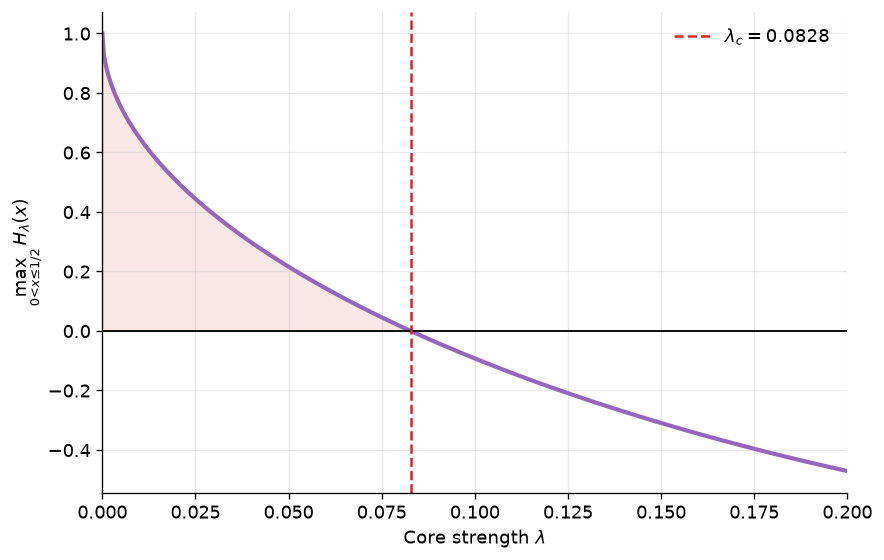

In [5]:
# Generate a range of x values for the monotonicity analysis
x = np.geomspace(1e-6, 0.5, 50_000)

# Calculate H
h_original = np.exp(-x) * (1 - 2 * x)
exp_minus_one = np.expm1(x)
h_logarithmic = (
    1 / exp_minus_one
    - 2 * x * np.exp(x) / exp_minus_one**2
)

# Calculate the minimum core strength required for a monotonic force
lambda_required = (
    h_original
    / (h_original - h_logarithmic)
)

# Find the critical core strength and its corresponding position
critical_index = np.argmax(lambda_required)
lambda_critical = lambda_required[critical_index]
x_critical = x[critical_index]

print(f"Critical core strength: {lambda_critical:.6f}")
print(f"Tangency position: x = {x_critical:.6f}")

# Generate a range of lambda values for the monotonicity measure
lambda_grid = np.linspace(0, 0.2, 500)
# Calculate the monotonicity measure for each lambda value
monotonicity_measure = np.array(
    [
        np.max(
            h_original
            + lambda_core
            * (h_logarithmic - h_original)
        )
        for lambda_core in lambda_grid
    ]
)

# Create a figure to visualize the monotonicity measure as a function of core strength
fig, ax = plt.subplots(
    figsize=(7.5, 4.8),
)

# Plot the monotonicity measure against the core strength
ax.plot(
    lambda_grid,
    monotonicity_measure,
    color="tab:purple",
    linewidth=2.5,
)
# Add horizontal and vertical lines to indicate critical values
ax.axhline(
    0,
    color="black",
    linewidth=1.1,
)
ax.axvline(
    lambda_critical,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=rf"$\lambda_c={lambda_critical:.4f}$",
)
# Fill the area where the monotonicity measure is positive
ax.fill_between(
    lambda_grid,
    monotonicity_measure,
    0,
    where=monotonicity_measure > 0,
    color="tab:red",
    alpha=0.10,
)
# Settings for the plot
ax.set(
    xlabel=r"Core strength $\lambda$",
    ylabel=r"$\max_{0<x\leq1/2} H_\lambda(x)$",
    xlim=(0, 0.2),
)
ax.legend()
fig.tight_layout()

save_figure(fig, "monotonicity_analysis")
plt.show()